In [1]:
import faraway.datasets.coagulation
import polars as pl
import matplotlib.pyplot as plt
coagulation = faraway.datasets.coagulation.load()

In [2]:
coagulation.head(3)

,coag,diet
1,62,A
2,60,A
3,63,A


Question

In the faraway package, we have a data set named "worldcup" giving various R: data on players from the 2010 World Cup. The variable "Time" tells us the time played in minutes by the various players. 

After you have installed and loaded the faraway package, find the average time played by using the command

 mean(worldcup$Time)

What is the average time played? You may round to 2 or three places after the decimal point. 



In [3]:
import requests
import pyreadr

#url = "https://raw.githubusercontent.com/julianfaraway/faraway/main/data/worldcup.rda"

#response = requests.get(url)
#response.raise_for_status()

#with open("worldcup.rda", "wb") as f:
#    f.write(response.content)

result = pyreadr.read_r("worldcup.rda")

print(result.keys())

df = result["worldcup"]

odict_keys(['worldcup'])


In [4]:
df = df.reset_index().rename(columns={"rownames":"Palyers"})

In [5]:
df['Time'].mean()

np.float64(208.86386554621848)

### Course plot

In [6]:
coagulation.groupby("diet").count()

,coag
diet,
A,4
B,6
C,6
D,8


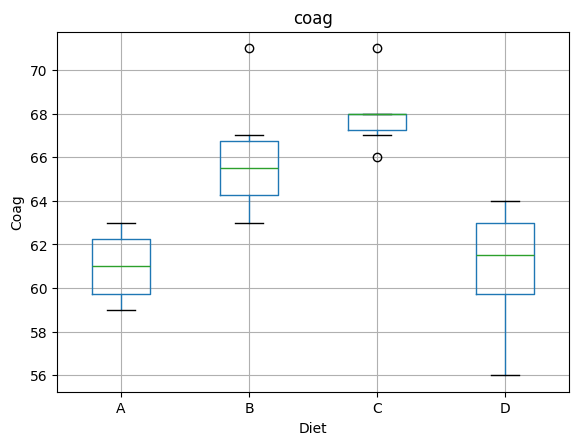

In [7]:
coagulation.boxplot(column="coag", by="diet")
plt.xlabel("Diet")
plt.ylabel("Coag")
plt.suptitle("")
plt.show()

### Concatenation, Five-number summary, Standard Deviation

In [8]:
import numpy as np

In [9]:
data_1 = np.array([35, 8, 10, 23, 42])

In [10]:
data_1.mean()

np.float64(23.6)

In [11]:
np.std(data_1, ddof=0)  # populacional (n)

np.float64(13.395521639712282)

In [12]:
np.std(data_1, ddof=1)  # amostral (n - 1)

np.float64(14.976648490233053)

# Média, Variância e Desvio Padrão

## Média

A média representa o valor central de um conjunto de dados.

$$
\bar{x} = \frac{x_1 + x_2 + x_3 + \cdots + x_n}{n}
$$

Ou, de forma compacta:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

---

## Variância populacional

Usada quando temos todos os dados da população.

$$
\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2
$$

Onde:

$$
\mu = \text{média populacional}
$$

---

## Desvio padrão populacional

O desvio padrão é a raiz quadrada da variância.

$$
\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2}
$$

---

## Variância amostral

Usada quando temos apenas uma amostra dos dados.

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2
$$

---

## Desvio padrão amostral

$$
s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}
$$

---

## Resumo

| Medida | Fórmula | Quando usar |
|---|---|---|
| Média | $\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i$ | Valor central dos dados |
| Variância populacional | $\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2$ | Quando temos todos os dados |
| Desvio padrão populacional | $\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2}$ | Quando temos todos os dados |
| Variância amostral | $s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$ | Quando temos uma amostra |
| Desvio padrão amostral | $s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$ | Quando temos uma amostra |

### Histogram

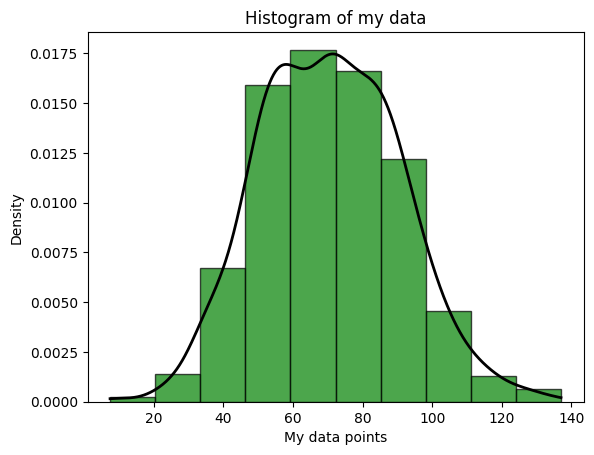

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

samples = np.random.normal(loc=70, scale=20, size=1000)

plt.title("Histogram of my data")

plt.hist(
    samples,
    density=True,
    edgecolor="black",
    color="green",
    alpha=0.7
)

density = gaussian_kde(samples)

x = np.linspace(samples.min(), samples.max(), 1000)
y = density(x)

plt.plot(x, y, color="black", linewidth=2)

plt.xlabel("My data points")
plt.ylabel("Density")
plt.show()

### Scatterplot

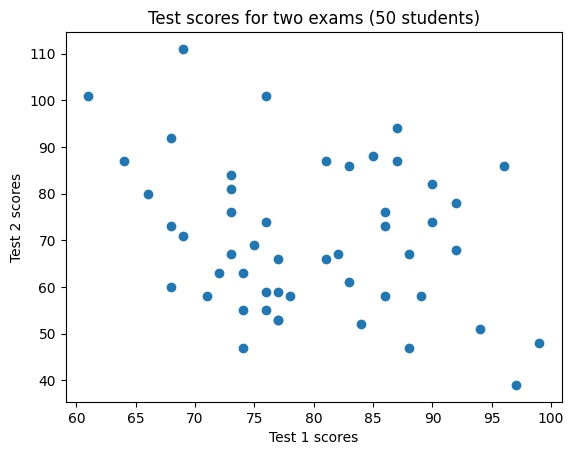

In [14]:
np.random.seed = 2016
test_1_score = np.round(np.random.normal(loc=78, scale=10, size=50))
test_2_score = np.round(np.random.normal(loc=70, scale=14, size=50))

plt.title("Test scores for two exams (50 students)");plt.scatter(test_1_score, test_2_score);
plt.xlabel("Test 1 scores");plt.ylabel("Test 2 scores");plt.show()

### Basic Statistics Review – Linear Regression

In [15]:
df_co2 = pl.read_csv("co2_mm_mlo.csv", has_header=True, comment_prefix="#")

In [16]:
df_co2.head(3)

year,month,decimal date,average,deseasonalized,ndays,sdev,unc
i64,i64,f64,f64,f64,i64,f64,f64
1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99


In [17]:
df_co2.describe()

statistic,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",818.0,818.0,818.0,818.0,818.0,818.0,818.0,818.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1991.750611,6.492665,1992.2494,361.024218,361.017873,19.166259,-2.006846,-0.086443
"""std""",19.69253,3.453212,19.690845,33.18909,33.130532,11.845258,4.487513,0.5091
"""min""",1958.0,1.0,1958.2027,312.42,314.44,-1.0,-9.99,-0.99
"""25%""",1975.0,3.0,1975.2083,331.07,330.84,14.0,0.2,0.08
"""50%""",1992.0,6.0,1992.2917,356.3,356.47,25.0,0.4,0.15
"""75%""",2009.0,9.0,2009.2917,387.33,387.24,28.0,0.57,0.22
"""max""",2026.0,12.0,2026.2917,431.12,428.72,31.0,1.31,0.58


In [18]:
df_co2 = df_co2.with_columns(
    date=pl.date(pl.col("year"), pl.col("month"), 1)
)

In [19]:
df_co2.head(3)

year,month,decimal date,average,deseasonalized,ndays,sdev,unc,date
i64,i64,f64,f64,f64,i64,f64,f64,date
1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99,1958-03-01
1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99,1958-04-01
1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99,1958-05-01


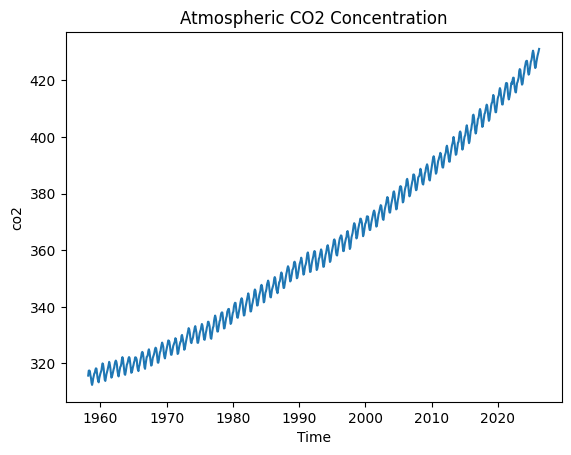

In [20]:
plt.title("Atmospheric CO2 Concentration");plt.xlabel("Time");plt.ylabel("co2")
plt.plot(
    df_co2["date"], 
    df_co2["average"])
plt.show()

##### Prediction Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
lm = LinearRegression()
lm.fit(df_co2["decimal date"].to_numpy().reshape(-1,1), df_co2["average"].to_numpy())

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Regressão Linear Simples

A equação geral de uma reta é dada por:

$$
y = mx + b
$$

Onde:

- $y$ é a **variável dependente**, ou seja, o valor que queremos prever.
- $x$ é a **variável independente**, ou seja, a variável usada para explicar ou prever $y$.
- $m$ é o **coeficiente angular** (*slope*), que representa a inclinação da reta.
- $b$ é o **intercepto**, ou seja, o valor de $y$ quando $x = 0$.

O coeficiente angular pode ser calculado por:

$$
m = \frac{y_2 - y_1}{x_2 - x_1}
$$

Essa fórmula mostra quanto $y$ varia quando $x$ aumenta uma unidade.

In [23]:
print(f"Ponto intercepto: {lm.intercept_:.3f} \nCoeficiente angular: {lm.coef_[0]:.3f}")

Ponto intercepto: -2955.614 
Coeficiente angular: 1.665


In [24]:
y_pred = lm.predict(df_co2["decimal date"].to_numpy().reshape(-1,1))

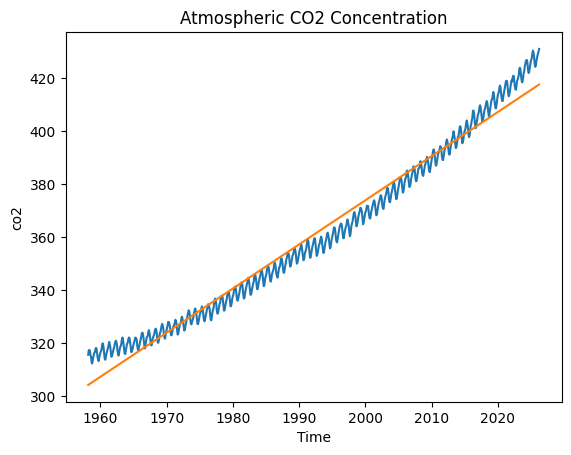

In [25]:
plt.title("Atmospheric CO2 Concentration");plt.xlabel("Time");plt.ylabel("co2")

plt.plot(
    df_co2["date"], 
    df_co2["average"]);

plt.plot(
    df_co2["date"], 
    y_pred);
plt.show()

### Ploting the residuals

In [31]:
residual = df_co2["average"] - y_pred

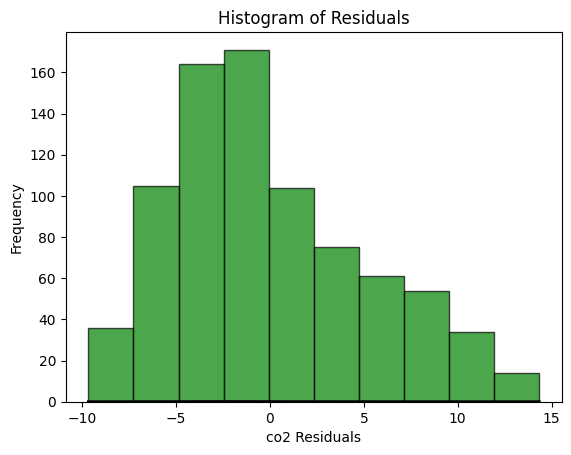

In [36]:
plt.title("Histogram of Residuals")

plt.hist(
    residual,
    density=False,
    edgecolor="black",
    color="green",
    alpha=0.7
)

density = gaussian_kde(residual)

x = np.linspace(residual.min(), residual.max(), 100)
y = density(x)

plt.plot(x, y, color="black", linewidth=2)

plt.xlabel("co2 Residuals")
plt.ylabel("Frequency")
plt.show()

#### Normal Q-Q Plot

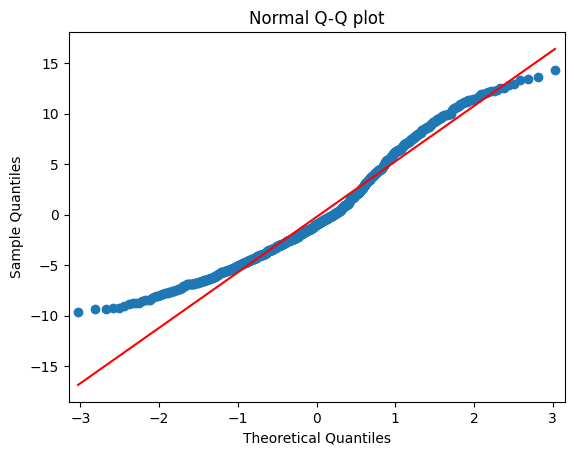

In [40]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Create the Normal Q-Q Plot (Equivalent to qqnorm + qqline)
fig = sm.qqplot(residual, line='q')

plt.title("Normal Q-Q plot")
plt.show()


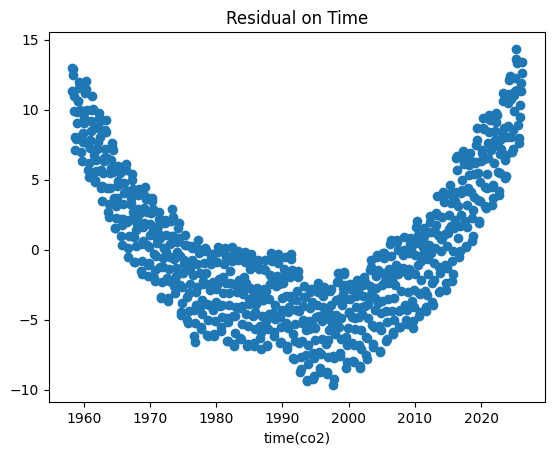

In [43]:
plt.title("Residual on Time");plt.scatter(df_co2["date"], residual);
plt.xlabel("time(co2)");
plt.show()

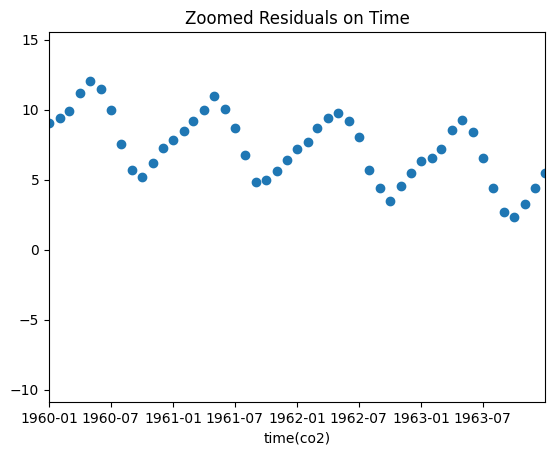

In [54]:
from datetime import date
import matplotlib.pyplot as plt

plt.title("Zoomed Residuals on Time")

plt.scatter(df_co2["date"].to_list(), residual)

plt.xlim(date(1960, 1, 1), date(1963, 12, 31))

plt.xlabel("time(co2)")
plt.show()